# Analysis of chunks
This notebook analyzes different chunking method's chunks from the data/runs directory, which contains run_XXXX folders. Each folder includes passages/passages.jsonl, queries/queries.jsonl, and metadata.json. It also uses the data/processed directory.

In [5]:
!pip install -r ../requirements.txt

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import tiktoken
from transformers import AutoTokenizer
from functools import lru_cache
import re
import json
import numpy as np
from tqdm import tqdm
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

TOKENIZER_TYPE = "gpt"
ENCODING_NAME = "o200k_base"

# Tokenizer


In [7]:
# --- cache tokenizerów (żeby nie ładować za każdym razem) ---
@lru_cache(maxsize=8)
def get_tiktoken_encoder(encoding_name: str):
    return tiktoken.get_encoding(encoding_name)


@lru_cache(maxsize=8)
def get_hf_tokenizer(model_name: str):
    return AutoTokenizer.from_pretrained(model_name)


def tokenize_text(
    text: str,
    tokenizer_type: str = TOKENIZER_TYPE,
    encoding_name: str = ENCODING_NAME,
    model_name: str = None,
    return_tokens: bool = True,
):
    """
    Uniwersalna tokenizacja (GPT / Qwen / LLaMA)

    Args:
        text (str): tekst wejściowy
        tokenizer_type (str): "gpt" | "hf"
        encoding_name (str): dla tiktoken
        model_name (str): dla HF (np. Qwen / LLaMA)
        return_tokens (bool): czy zwracać tokeny czy tylko count

    Returns:
        list[int] lub int
    """

    if tokenizer_type == "gpt":
        enc = get_tiktoken_encoder(encoding_name)
        tokens = enc.encode(text)

    elif tokenizer_type == "hf":
        if model_name is None:
            raise ValueError("model_name musi być podany dla HF tokenizer")

        tokenizer = get_hf_tokenizer(model_name)
        tokens = tokenizer.encode(text)

    else:
        raise ValueError(f"Nieznany tokenizer_type: {tokenizer_type}")

    return tokens if return_tokens else len(tokens)

def count_tokens(text: str, encoding_name: str = "o200k_base") -> int:
    return len(tokenize_text(text))

# Check end of sentence

In [8]:

# ── stałe ───────────────────────────────────────────────────────────────────

# Skróty PL + EN kończące się kropką (nie są końcem zdania)
_ABBREVS = re.compile(
    r"\b("
    # polskie
    r"np|m\.in|tzn|tj|itd|itp|cdn"
    r"|ul|al|pl|os|woj|gm|pow"
    r"|dr|prof|mgr|inż|lic|hab|ks|św"
    r"|godz|min|sek|tys|mln|mld|ok|ok\.o"
    r"|nr|str|rozdz|rys|tab|zob|por"
    # angielskie
    r"|etc|vs|approx|ca|est|fig|ref|dept|govt|corp|inc|ltd|llc"
    r"|mr|mrs|ms|dr|prof|sr|jr|rev|gen|sgt|cpl|pvt|cmdr"
    r"|jan|feb|mar|apr|jun|jul|aug|sep|oct|nov|dec"  # miesiące
    r"|st|ave|blvd|rd|hwy"                           # adresy
    r"|vol|no|pp|ed|eds|trans|repr"                  # publikacje
    r"|[a-záćęłńóśźż]"                              # pojedyncza litera (inicjał)
    r")\.$",
    re.IGNORECASE,
)

# Koniec zdania: . ! ? opcjonalnie z cudzysłowem/nawiasem
_SENTENCE_END = re.compile(r'[.!?]["\')\]»›]?$')

# Wielkie litery PL + EN (bez rozszerzania — Unicode \p{Lu} niedostępne bez regex lib)
_UPPER_ALNUM = re.compile(r"[A-ZĄĆĘŁŃÓŚŹŻ0-9]")

# Wzorce startu nowej jednostki strukturalnej
_STRUCT_START = re.compile(
    r"^("
    r"\#{1,6}\s"             # nagłówek Markdown
    r"|[-*•–]\s"             # lista nieuporządkowana
    r"|\d+[.)]\s"            # lista numerowana
    r"|[A-ZĄĆĘŁŃÓŚŹŻ]"       # wielka litera PL/EN → nowe zdanie
    r")"
)


# ── pomocnicze ───────────────────────────────────────────────────────────────

def _has_paragraph_break(text: str) -> bool:
    """True jeśli tekst zawiera przerwę paragrafową (pusta linia)."""
    return bool(re.search(r"\n[ \t]*\n", text))


def _first_alphanum(text: str) -> str | None:
    """Zwraca pierwszy znak alfanumeryczny z tekstu (pomija whitespace/znaki spec.)"""
    m = re.search(r"[A-ZĄĆĘŁŃÓŚŹŻ0-9]", text, re.IGNORECASE)
    return m.group(0) if m else None


def _next_starts_clean_after_newline(nxt: str) -> bool:
    """
    True jeśli `nxt` zaczyna się od nowej linii (lub białych znaków z \n),
    a pierwszy znak alfanumeryczny to wielka litera (PL lub EN) lub cyfra.
    Semantyka: pojedynczy \n + wielka litera/cyfra = akceptowalny podział.
    """
    if not re.match(r"[ \t]*\n", nxt) and not nxt.startswith("\n"):
        return False
    first = _first_alphanum(nxt)
    if first is None:
        return False
    return bool(re.match(r"[A-ZĄĆĘŁŃÓŚŹŻ0-9]", first))


def ends_with_sentence(text: str) -> bool:
    """
    True jeśli tekst kończy się końcem zdania, z wykluczeniem skrótów.
    Obsługuje PL i EN.
    """
    t = text.rstrip()
    if not _SENTENCE_END.search(t):
        return False
    last_word = t.rsplit(None, 1)[-1] if t else ""
    return not _ABBREVS.match(last_word)


def ends_with_structure(text: str) -> bool:
    """
    True jeśli chunk kończy się elementem strukturalnym:
    pusta linia (paragraf) lub nagłówek Markdown.
    """
    if _has_paragraph_break(text):
        return True
    if re.search(r"\#{1,6}[^\n]*$", text.rstrip()):
        return True
    return False


def starts_like_new_unit(text: str) -> bool:
    """
    True jeśli chunk zaczyna się jak nowa jednostka (nagłówek, lista, wielka litera PL/EN).
    Nie traktuje cyfr jako bezwarunkowego startu — cyfry obsługiwane przez newline-logikę.
    """
    return bool(_STRUCT_START.match(text.lstrip()))


# ── wynik ────────────────────────────────────────────────────────────────────

class ChunkBoundaryResult:
    def __init__(self, ok: bool, reason: str):
        self.ok = ok
        self.reason = reason

    def __bool__(self):
        return self.ok

    def __repr__(self):
        status = "✓ OK" if self.ok else "✗ ZŁY PODZIAŁ"
        return f"ChunkBoundary({status}: {self.reason})"


# ── główna funkcja ───────────────────────────────────────────────────────────

def check_chunk_boundary(curr: str, nxt: str) -> ChunkBoundaryResult:
    """
    Ocenia czy granica między `curr` a `nxt` jest poprawna.
    Obsługuje teksty polskie i angielskie.

    Hierarchia sygnałów (od najsilniejszego):
      1. Pusty curr                          → OK
      2. curr kończy się strukturą           → OK  (paragraf, nagłówek)
      3. curr kończy się zdaniem             → OK, chyba że nxt małą literą
      4. curr kończy \n + nxt wielka/cyfra   → OK  (nowa linia = dobry podział)
      5. nxt zaczyna nową jednostkę          → OK
      6. Brak sygnałów                       → ZŁY PODZIAŁ
    """
    if not curr.strip():
        return ChunkBoundaryResult(True, "pusty chunk")

    # 1. koniec struktury (paragraf / nagłówek)
    if ends_with_structure(curr):
        return ChunkBoundaryResult(True, "koniec struktury (paragraf/nagłówek)")

    # 2. koniec zdania
    if ends_with_sentence(curr):
        nxt_stripped = nxt.lstrip()
        if nxt_stripped and nxt_stripped[0].islower():
            return ChunkBoundaryResult(
                False,
                f"curr kończy zdaniem, ale nxt zaczyna małą literą: {nxt_stripped[:30]!r}"
            )
        return ChunkBoundaryResult(True, "koniec zdania")

    # 3. curr kończy się \n, a nxt zaczyna wielką literą lub cyfrą
    if curr.rstrip(" \t").endswith("\n") and _next_starts_clean_after_newline(nxt):
        first = _first_alphanum(nxt)
        kind = "cyfrą" if first and first.isdigit() else "wielką literą"
        return ChunkBoundaryResult(True, f"nowa linia + nxt zaczyna się {kind}")

    # 4. nxt zaczyna nową jednostkę strukturalną (nagłówek, lista, wielka litera)
    if starts_like_new_unit(nxt):
        return ChunkBoundaryResult(True, "nxt zaczyna nową jednostkę strukturalną")

    # 5. brak sygnałów
    curr_tail = curr.rstrip()[-40:]
    nxt_head = nxt.lstrip()[:40]
    return ChunkBoundaryResult(
        False,
        f"przecięte zdanie: ...{curr_tail!r} | {nxt_head!r}..."
    )


# zachowana dla kompatybilności wstecznej
def is_end_sentence(curr: str, nxt: str) -> bool:
    return check_chunk_boundary(curr, nxt).ok

# Process single chunk

In [9]:
def process_chunk(curr_obj, next_obj, tokenizer_kwargs):
    curr_text = curr_obj.get("contents", "")
    curr_meta = curr_obj.get("metadata", {})
    curr_parent = curr_meta.get("parentId")

    next_text = ""
    next_parent = None

    if next_obj:
        next_text = next_obj.get("contents", "")
        next_parent = next_obj.get("metadata", {}).get("parentId")

    # --- tokeny ---
    tokens = tokenize_text(curr_text, **tokenizer_kwargs)
    token_count = len(tokens)

    # --- label ---
    if next_obj is None or curr_parent != next_parent:
        label = "end_file"
    else:
        good = is_end_sentence(curr_text, next_text)
        label = "good" if good else "fail"

    return {
        "tokens": tokens,
        "token_count": token_count,
        "parentId": curr_parent,
        "label": label,
        
        
    }

# Process single run

In [10]:
def chunking_metrics(passages_path: str, tokenizer_kwargs=None):
    if tokenizer_kwargs is None:
        tokenizer_kwargs = {"tokenizer_type": "gpt"}

    token_counts = []
    labels = []

    min_tokens = float("inf")
    max_tokens = float("-inf")
    min_id = None
    max_id = None
    with open(passages_path, "r", encoding="utf-8") as f:
        total_lines = sum(1 for _ in f)
    with open(passages_path, "r", encoding="utf-8") as f:
        prev_obj = None

        for line in tqdm(f, total=total_lines, desc="chunking passages", unit="line"):
            curr_obj = json.loads(line)

            if prev_obj is not None:
                result = process_chunk(prev_obj, curr_obj, tokenizer_kwargs)
                tokens_count = result["token_count"]
                chunk_id = prev_obj.get("id")
                
                token_counts.append(tokens_count)
                labels.append(result["label"])

                # --- min ---
                if tokens_count < min_tokens:
                    min_tokens = tokens_count
                    min_id = chunk_id

                # --- max ---
                if tokens_count > max_tokens:
                    max_tokens = tokens_count
                    max_id = chunk_id

            prev_obj = curr_obj

        # ostatni element
        if prev_obj is not None:
            result = process_chunk(prev_obj, None, tokenizer_kwargs)

            tokens_count = result["token_count"]
            chunk_id = prev_obj.get("id")

            token_counts.append(tokens_count)
            labels.append(result["label"])

            if tokens_count < min_tokens:
                min_tokens = tokens_count
                min_id = chunk_id

            if tokens_count > max_tokens:
                max_tokens = tokens_count
                max_id = chunk_id

    if not token_counts:
        return None

    arr = np.array(token_counts)

    metrics = {
        "token_counts": token_counts,
        "mean": float(np.mean(arr)),
        "median": float(np.median(arr)),
        "std": float(np.std(arr)),

        # 🔥 zmienione:
        "min": {
            "value": int(min_tokens),
            "id": min_id,
        },
        "max": {
            "value": int(max_tokens),
            "id": max_id,
        },

        "p10": float(np.percentile(arr, 10)),
        "p25": float(np.percentile(arr, 25)),
        "p50": float(np.percentile(arr, 50)),
        "p75": float(np.percentile(arr, 75)),
        "p90": float(np.percentile(arr, 90)),
        "p95": float(np.percentile(arr, 95)),
        "p99": float(np.percentile(arr, 99)),

        "good_ratio": labels.count("good") / len(labels),
        "fail_ratio": labels.count("fail") / len(labels),
        "end_file_ratio": labels.count("end_file") / len(labels),
    }

    return metrics

# Analyze all runs

In [ ]:
def build_dataframe(data_dir: str) -> pd.DataFrame:
    rows = []
    datasets_names = os.listdir(data_dir)
    for i, dataset_name in enumerate(datasets_names):
        
        dataset_path = os.path.join(data_dir, dataset_name)

        if not os.path.isdir(dataset_path):
            continue

        metadata_path = os.path.join(dataset_path, "metadata.json")
        passages_path = os.path.join(dataset_path, "passages", "passages.jsonl")

        if not os.path.exists(metadata_path):
            continue

        # --- wczytaj metadata ---
        with open(metadata_path, "r", encoding="utf-8") as f:
            metadata = json.load(f)

        # --- wyciągnij pola ---
        dataset_slug = metadata.get("dataset_slug")
        chunker_name = metadata.get("chunker_name")
        document_count = metadata.get("document_count")
        chunk_count = metadata.get("chunk_count")

        timing = metadata.get("timing", {})
        chunking_seconds = timing.get("chunking_seconds")
        print(f"Processing dataset: {dataset_slug}, run number {i+1}/{len(datasets_names)}")
        # --- metryki chunkingu ---
        metrics = None
        if os.path.exists(passages_path):
            metrics = chunking_metrics(passages_path)

        # --- row ---
        row = {
            "dataset_slug": dataset_slug,
            "chunker_name": chunker_name,
            "document_count": document_count,
            "chunk_count": chunk_count,
            "chunking_seconds": chunking_seconds,
            "metrics": metrics,
        }

        rows.append(row)
        

    df = pd.DataFrame(rows)
    return df

# PLots

In [12]:
# ── Globalne ustawienia stylu ─────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     11,
    "axes.titleweight":   "bold",
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
})
 
PALETTE = [
    "#3266ad", "#e06c2b", "#2da068", "#a0449e",
    "#c8352e", "#5bacd4", "#d4a017", "#7b5ea7",
]
GOOD_C  = "#2da068"
FAIL_C  = "#c8352e"
END_C   = "#e06c2b"
 
 
# ──────────────────────────────────────────────────────────────────────
# Przygotowanie danych
# ──────────────────────────────────────────────────────────────────────
def extract_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, r in df.iterrows():
        m = r["metrics"]
        rows.append({
            "dataset_slug":     r["dataset_slug"],
            "chunker_name":     r["chunker_name"],
            "document_count":   r["document_count"],
            "chunk_count":      r["chunk_count"],
            "chunking_seconds": r["chunking_seconds"],
            "token_counts":     m["token_counts"],
            "mean":             m["mean"],
            "median":           m["median"],
            "std":              m["std"],
            "min_val":          m["min"]["value"],
            "max_val":          m["max"]["value"],
            "p10":  m["p10"],  "p25": m["p25"], "p50": m["p50"],
            "p75":  m["p75"],  "p90": m["p90"], "p95": m["p95"], "p99": m["p99"],
            "good_ratio":     m["good_ratio"],
            "fail_ratio":     m["fail_ratio"],
            "end_file_ratio": m["end_file_ratio"],
            "good_end_ratio": m["good_ratio"] + m["end_file_ratio"],
        })
    flat = pd.DataFrame(rows)
    # overlap per dataset: (mean - min_mean) / min_mean * 100
    flat["overlap_pct"] = flat.groupby("dataset_slug")["mean"].transform(
        lambda x: ((x - x.min()) / x.min() * 100).round(1)
    )
    return flat
 
 
def _chunker_color_map(flat: pd.DataFrame) -> dict:
    """Stały mapping chunker → kolor (spójny we wszystkich wykresach)."""
    chunkers = sorted(flat["chunker_name"].unique())
    return {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(chunkers)}
 
 
def _legend_handles(cmap: dict) -> list:
    return [
        mpatches.Patch(color=col, label=name)
        for name, col in cmap.items()
    ]
 
 
# ──────────────────────────────────────────────────────────────────────
# Pomocnicze
# ──────────────────────────────────────────────────────────────────────
def _add_bar_labels(ax, fmt="{:.1f}", fontsize=8, padding=2):
    """Dodaje etykiety wartości nad/obok każdego bara."""
    for patch in ax.patches:
        h = patch.get_height()
        if h == 0 or np.isnan(h):
            continue
        ax.annotate(
            fmt.format(h),
            xy=(patch.get_x() + patch.get_width() / 2, h),
            xytext=(0, padding),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=fontsize,
        )
 
 
def _col_count(n_datasets: int) -> int:
    return min(n_datasets, 3)
 
 
def _fig_size(n_datasets: int, h_per_row: float = 4.0) -> tuple:
    cols = _col_count(n_datasets)
    rows = math.ceil(n_datasets / cols)
    return (cols * 5.5, rows * h_per_row)
 
 
# ──────────────────────────────────────────────────────────────────────
# 1. Tabela: liczba dokumentów per dataset
# ──────────────────────────────────────────────────────────────────────
def fig_doc_table(flat: pd.DataFrame) -> plt.Figure:
    summary = (
        flat.groupby("dataset_slug")
        .agg(
            document_count=("document_count", "first"),
            n_chunkers=("chunker_name", "nunique"),
            chunkers=("chunker_name", lambda x: ", ".join(sorted(set(x)))),
        )
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(max(8, len(summary) * 2.5), 1.2 + len(summary) * 0.45))
    ax.axis("off")
    col_labels = ["Dataset", "Dokumenty", "Liczba chunkerów", "Chunkery"]
    table_data = [
        [r["dataset_slug"], f"{r['document_count']:,}", str(r["n_chunkers"]), r["chunkers"]]
        for _, r in summary.iterrows()
    ]
    tbl = ax.table(
        cellText=table_data,
        colLabels=col_labels,
        cellLoc="left",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.auto_set_column_width(list(range(len(col_labels))))
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("#cccccc")
        if row == 0:
            cell.set_facecolor("#dde8ff")
            cell.set_text_props(fontweight="bold")
        else:
            cell.set_facecolor("white" if row % 2 == 0 else "#f7f9ff")
    fig.suptitle("Liczba dokumentów per dataset", fontsize=13, fontweight="bold", y=0.98)
    fig.tight_layout()
    return fig
 
 
# ──────────────────────────────────────────────────────────────────────
# 2. Tabela: overlap mean tokenów
# ──────────────────────────────────────────────────────────────────────
def fig_overlap_table(flat: pd.DataFrame) -> plt.Figure:
    datasets  = sorted(flat["dataset_slug"].unique())
    n_ds      = len(datasets)
    cols_grid = _col_count(n_ds)
    rows_grid = math.ceil(n_ds / cols_grid)
 
    fig, axes = plt.subplots(
        rows_grid, cols_grid,
        figsize=(cols_grid * 5.5, rows_grid * (2.0 + flat.groupby("dataset_slug").size().max() * 0.42)),
    )
    axes = np.array(axes).flatten()
 
    for idx, slug in enumerate(datasets):
        ax = axes[idx]
        ax.axis("off")
        d = flat[flat["dataset_slug"] == slug].sort_values("overlap_pct")
        col_labels = ["Chunker", "Mean tokenów", "Overlap %"]
        table_data = [
            [
                r["chunker_name"],
                f"{r['mean']:.1f}",
                "0.0% (baseline)" if r["overlap_pct"] == 0 else f"{r['overlap_pct']:.1f}%",
            ]
            for _, r in d.iterrows()
        ]
        tbl = ax.table(cellText=table_data, colLabels=col_labels, cellLoc="left", loc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.auto_set_column_width([0, 1, 2])
        for (row, col), cell in tbl.get_celld().items():
            cell.set_edgecolor("#cccccc")
            if row == 0:
                cell.set_facecolor("#dde8ff")
                cell.set_text_props(fontweight="bold")
            else:
                val = table_data[row - 1][2]
                cell.set_facecolor("#e8f5e9" if "baseline" in val else "#e3f0fb")
        ax.set_title(slug, fontsize=10, fontweight="bold", pad=6)
 
    for idx in range(len(datasets), len(axes)):
        axes[idx].axis("off")
 
    fig.suptitle(
        "Względny overlap średniej długości chunków\n"
        "wzór: (mean − min_mean) / min_mean × 100%",
        fontsize=13, fontweight="bold",
    )
    fig.tight_layout()
    return fig
 
 
# ──────────────────────────────────────────────────────────────────────
# 3. Bar: chunk_count per chunker × dataset
# ──────────────────────────────────────────────────────────────────────
def fig_chunk_count(flat: pd.DataFrame, cmap: dict) -> plt.Figure:
    datasets  = sorted(flat["dataset_slug"].unique())
    n_ds      = len(datasets)
    cols_grid = _col_count(n_ds)
    rows_grid = math.ceil(n_ds / cols_grid)
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=_fig_size(n_ds, 4.0))
    axes = np.array(axes).flatten()
 
    for idx, slug in enumerate(datasets):
        ax = axes[idx]
        d = flat[flat["dataset_slug"] == slug].copy()
        x = np.arange(len(d))
        bars = ax.bar(x, d["chunk_count"], color=[cmap[c] for c in d["chunker_name"]], width=0.6, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels(d["chunker_name"], rotation=25, ha="right", fontsize=8)
        ax.set_title(slug, fontsize=10, fontweight="bold")
        ax.set_ylabel("chunk_count", fontsize=8)
        ax.yaxis.grid(True, zorder=0)
        ax.set_axisbelow(True)
        # etykiety
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{int(h):,}", xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7)
 
    for idx in range(len(datasets), len(axes)):
        axes[idx].axis("off")
 
    fig.legend(handles=_legend_handles(cmap), title="Chunker",
               loc="lower center", ncol=len(cmap), fontsize=8,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Liczba chunków (chunk_count)", fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig
 
 
# ──────────────────────────────────────────────────────────────────────
# 4. Bar: chunking_seconds per chunker × dataset
# ──────────────────────────────────────────────────────────────────────
def fig_chunking_seconds(flat: pd.DataFrame, cmap: dict) -> plt.Figure:
    datasets  = sorted(flat["dataset_slug"].unique())
    n_ds      = len(datasets)
    cols_grid = _col_count(n_ds)
    rows_grid = math.ceil(n_ds / cols_grid)
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=_fig_size(n_ds, 4.0))
    axes = np.array(axes).flatten()
 
    for idx, slug in enumerate(datasets):
        ax = axes[idx]
        d = flat[flat["dataset_slug"] == slug].copy()
        x = np.arange(len(d))
        bars = ax.bar(x, d["chunking_seconds"], color=[cmap[c] for c in d["chunker_name"]], width=0.6, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels(d["chunker_name"], rotation=25, ha="right", fontsize=8)
        ax.set_title(slug, fontsize=10, fontweight="bold")
        ax.set_ylabel("sekundy", fontsize=8)
        ax.yaxis.grid(True, zorder=0)
        ax.set_axisbelow(True)
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{h:.1f}s", xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7)
 
    for idx in range(len(datasets), len(axes)):
        axes[idx].axis("off")
 
    fig.legend(handles=_legend_handles(cmap), title="Chunker",
               loc="lower center", ncol=len(cmap), fontsize=8,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Czas chunkowania (chunking_seconds)", fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig
 
 
# ──────────────────────────────────────────────────────────────────────
# 5. Boxplot: rozkład długości tokenów per chunker × dataset
# ──────────────────────────────────────────────────────────────────────
def fig_boxplot_tokens(flat: pd.DataFrame, cmap: dict) -> plt.Figure:
    datasets  = sorted(flat["dataset_slug"].unique())
    n_ds      = len(datasets)
    cols_grid = _col_count(n_ds)
    rows_grid = math.ceil(n_ds / cols_grid)
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=_fig_size(n_ds, 5.0))
    axes = np.array(axes).flatten()
 
    for idx, slug in enumerate(datasets):
        ax = axes[idx]
        d = flat[flat["dataset_slug"] == slug].copy()
        chunkers = d["chunker_name"].tolist()
        data     = [r["token_counts"] for _, r in d.iterrows()]
        colors   = [cmap[c] for c in chunkers]
 
        bp = ax.boxplot(
            data,
            labels=chunkers,
            patch_artist=True,
            showfliers=True,
            flierprops=dict(marker="o", markersize=2.5, alpha=0.4, linestyle="none"),
            medianprops=dict(color="black", linewidth=1.5),
            whiskerprops=dict(linewidth=1),
            capprops=dict(linewidth=1),
        )
        for patch, col in zip(bp["boxes"], colors):
            patch.set_facecolor(col)
            patch.set_alpha(0.65)
        for flier, col in zip(bp["fliers"], colors):
            flier.set_markerfacecolor(col)
            flier.set_markeredgecolor(col)
 
        # mediana jako etykieta
        for i, med_line in enumerate(bp["medians"]):
            med_val = med_line.get_ydata()[0]
            x_pos   = med_line.get_xdata().mean()
            ax.annotate(f"{med_val:.0f}", xy=(x_pos, med_val),
                        xytext=(0, 4), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7, color="black")
 
        ax.set_xticklabels(chunkers, rotation=25, ha="right", fontsize=8)
        ax.set_title(slug, fontsize=10, fontweight="bold")
        ax.set_ylabel("długość [tokeny]", fontsize=8)
        ax.yaxis.grid(True, zorder=0)
        ax.set_axisbelow(True)
 
    for idx in range(len(datasets), len(axes)):
        axes[idx].axis("off")
 
    fig.legend(handles=_legend_handles(cmap), title="Chunker",
               loc="lower center", ncol=len(cmap), fontsize=8,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Rozkład długości chunków [tokeny] — boxplot z outlierami", fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig
 
 
# ──────────────────────────────────────────────────────────────────────
# 6. Ratio bars: good / fail / end_file / good+end per chunker × dataset
# ──────────────────────────────────────────────────────────────────────
def _ratio_bars(flat, datasets, cmap, metric, color, title, fmt="{:.1f}%", ylabel="%"):
    n_ds      = len(datasets)
    cols_grid = _col_count(n_ds)
    rows_grid = math.ceil(n_ds / cols_grid)
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=_fig_size(n_ds, 3.8))
    axes = np.array(axes).flatten()
 
    for idx, slug in enumerate(datasets):
        ax = axes[idx]
        d = flat[flat["dataset_slug"] == slug].copy()
        vals = (d[metric] * 100).round(1)
        x    = np.arange(len(d))
        bars = ax.bar(x, vals, color=color, width=0.6, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels(d["chunker_name"], rotation=25, ha="right", fontsize=8)
        ax.set_title(slug, fontsize=10, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=8)
        ax.set_ylim(0, 108)
        ax.yaxis.grid(True, zorder=0)
        ax.set_axisbelow(True)
        for bar in bars:
            h = bar.get_height()
            ax.annotate(fmt.format(h), xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7)
 
    for idx in range(len(datasets), len(axes)):
        axes[idx].axis("off")
 
    fig.legend(handles=_legend_handles(cmap), title="Chunker",
               loc="lower center", ncol=len(cmap), fontsize=8,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig
 
 
def fig_good_ratio(flat: pd.DataFrame, cmap: dict) -> plt.Figure:
    return _ratio_bars(flat, sorted(flat["dataset_slug"].unique()), cmap,
                       "good_ratio", GOOD_C, "good_ratio (%)")
 
 
def fig_fail_ratio(flat: pd.DataFrame, cmap: dict) -> plt.Figure:
    return _ratio_bars(flat, sorted(flat["dataset_slug"].unique()), cmap,
                       "fail_ratio", FAIL_C, "fail_ratio (%)")
 
 
def fig_end_file_ratio(flat: pd.DataFrame, cmap: dict) -> plt.Figure:
    return _ratio_bars(flat, sorted(flat["dataset_slug"].unique()), cmap,
                       "end_file_ratio", END_C, "end_file_ratio (%)")
 
 
# ──────────────────────────────────────────────────────────────────────
# 7. Stacked bar: good + end_file per chunker × dataset
# ──────────────────────────────────────────────────────────────────────
def fig_good_end_stacked(flat: pd.DataFrame, cmap: dict) -> plt.Figure:
    datasets  = sorted(flat["dataset_slug"].unique())
    n_ds      = len(datasets)
    cols_grid = _col_count(n_ds)
    rows_grid = math.ceil(n_ds / cols_grid)
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=_fig_size(n_ds, 4.0))
    axes = np.array(axes).flatten()
 
    for idx, slug in enumerate(datasets):
        ax = axes[idx]
        d = flat[flat["dataset_slug"] == slug].copy()
        x        = np.arange(len(d))
        good     = (d["good_ratio"] * 100).round(1).values
        end_file = (d["end_file_ratio"] * 100).round(1).values
        total    = (good + end_file).round(1)
 
        ax.bar(x, good,     color=GOOD_C, width=0.6, label="good_ratio",     zorder=3)
        ax.bar(x, end_file, color=END_C,  width=0.6, label="end_file_ratio", bottom=good, zorder=3)
 
        ax.set_xticks(x)
        ax.set_xticklabels(d["chunker_name"], rotation=25, ha="right", fontsize=8)
        ax.set_title(slug, fontsize=10, fontweight="bold")
        ax.set_ylabel("%", fontsize=8)
        ax.set_ylim(0, 115)
        ax.yaxis.grid(True, zorder=0)
        ax.set_axisbelow(True)
 
        for xi, tot in zip(x, total):
            ax.annotate(f"{tot:.1f}%", xy=(xi, tot),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7)
 
    for idx in range(len(datasets), len(axes)):
        axes[idx].axis("off")
 
    # legenda stacka + legenda chunkerów
    stack_handles = [
        mpatches.Patch(color=GOOD_C, label="good_ratio"),
        mpatches.Patch(color=END_C,  label="end_file_ratio"),
    ]
    fig.legend(handles=stack_handles + _legend_handles(cmap),
               title="Kolor segmentu / Chunker",
               loc="lower center", ncol=len(cmap) + 2, fontsize=8,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("good_ratio + end_file_ratio (stacked, %)", fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig
 
 
# ──────────────────────────────────────────────────────────────────────
# Główne API
# ──────────────────────────────────────────────────────────────────────
def build_all_figures(df: pd.DataFrame) -> dict:
    """
    Buduje wszystkie figury. Zwraca słownik:
      {
        "doc_table":       Figure,
        "overlap_table":   Figure,
        "chunk_count":     Figure,
        "chunking_secs":   Figure,
        "boxplot_tokens":  Figure,
        "good_ratio":      Figure,
        "fail_ratio":      Figure,
        "end_file_ratio":  Figure,
        "good_end_stack":  Figure,
      }
    """
    flat = extract_metrics(df)
    cmap = _chunker_color_map(flat)
    return {
        "doc_table":      fig_doc_table(flat),
        "overlap_table":  fig_overlap_table(flat),
        "chunk_count":    fig_chunk_count(flat, cmap),
        "chunking_secs":  fig_chunking_seconds(flat, cmap),
        "boxplot_tokens": fig_boxplot_tokens(flat, cmap),
        "good_ratio":     fig_good_ratio(flat, cmap),
        "fail_ratio":     fig_fail_ratio(flat, cmap),
        "end_file_ratio": fig_end_file_ratio(flat, cmap),
        "good_end_stack": fig_good_end_stacked(flat, cmap),
    }
 
 
def show_dashboard(df: pd.DataFrame) -> None:
    """Wyświetla wszystkie wykresy w osobnych oknach."""
    figs = build_all_figures(df)
    for fig in figs.values():
        fig.show()
    plt.show()
 
 
def save_dashboard(df: pd.DataFrame, path: str = "chunker_dashboard.pdf") -> None:
    """
    Zapisuje wszystkie wykresy do jednego pliku.
    Obsługiwane formaty: .pdf (wielostronicowy), .png, .svg (ostatni wykres).
    Dla PNG/SVG zapisuje każdy wykres osobno: nazwa_0.png, nazwa_1.png, ...
    """
    figs = build_all_figures(df)
 
    if path.endswith(".pdf"):
        from matplotlib.backends.backend_pdf import PdfPages
        with PdfPages(path) as pdf:
            for fig in figs.values():
                pdf.savefig(fig, bbox_inches="tight")
        print(f"Zapisano: {path}")
    else:
        base, ext = path.rsplit(".", 1)
        for i, (name, fig) in enumerate(figs.items()):
            out = f"{base}_{i:02d}_{name}.{ext}"
            fig.savefig(out, bbox_inches="tight", dpi=150)
            print(f"Zapisano: {out}")
 
    plt.close("all")

# Results

In [15]:
df = build_dataframe("../data/runs")


Processing dataset: gutenqa_all, run number 1


chunking passages: 100%|██████████| 159541/159541 [00:14<00:00, 11079.04line/s]


Processing dataset: gutenqa_all_merged, run number 2


chunking passages: 100%|██████████| 145148/145148 [00:14<00:00, 10303.32line/s]


Processing dataset: literaryqa_validation, run number 3


...

chunking passages: 100%|██████████| 19115/19115 [00:02<00:00, 8528.69line/s]


Processing dataset: gutenqa_all, run number 54


chunking passages: 100%|██████████| 101398/101398 [00:12<00:00, 8386.58line/s]


Processing dataset: literaryqa_validation, run number 55


chunking passages: 100%|██████████| 23105/23105 [00:04<00:00, 5507.31line/s]


C:\Users\admin\AppData\Local\Temp\ipykernel_44788\541338557.py:289: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\admin\AppData\Local\Temp\ipykernel_44788\541338557.py:289: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\admin\AppData\Local\Temp\ipykernel_44788\541338557.py:289: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\admin\AppData\Local\Temp\ipykernel_44788\541338557.py:289: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3

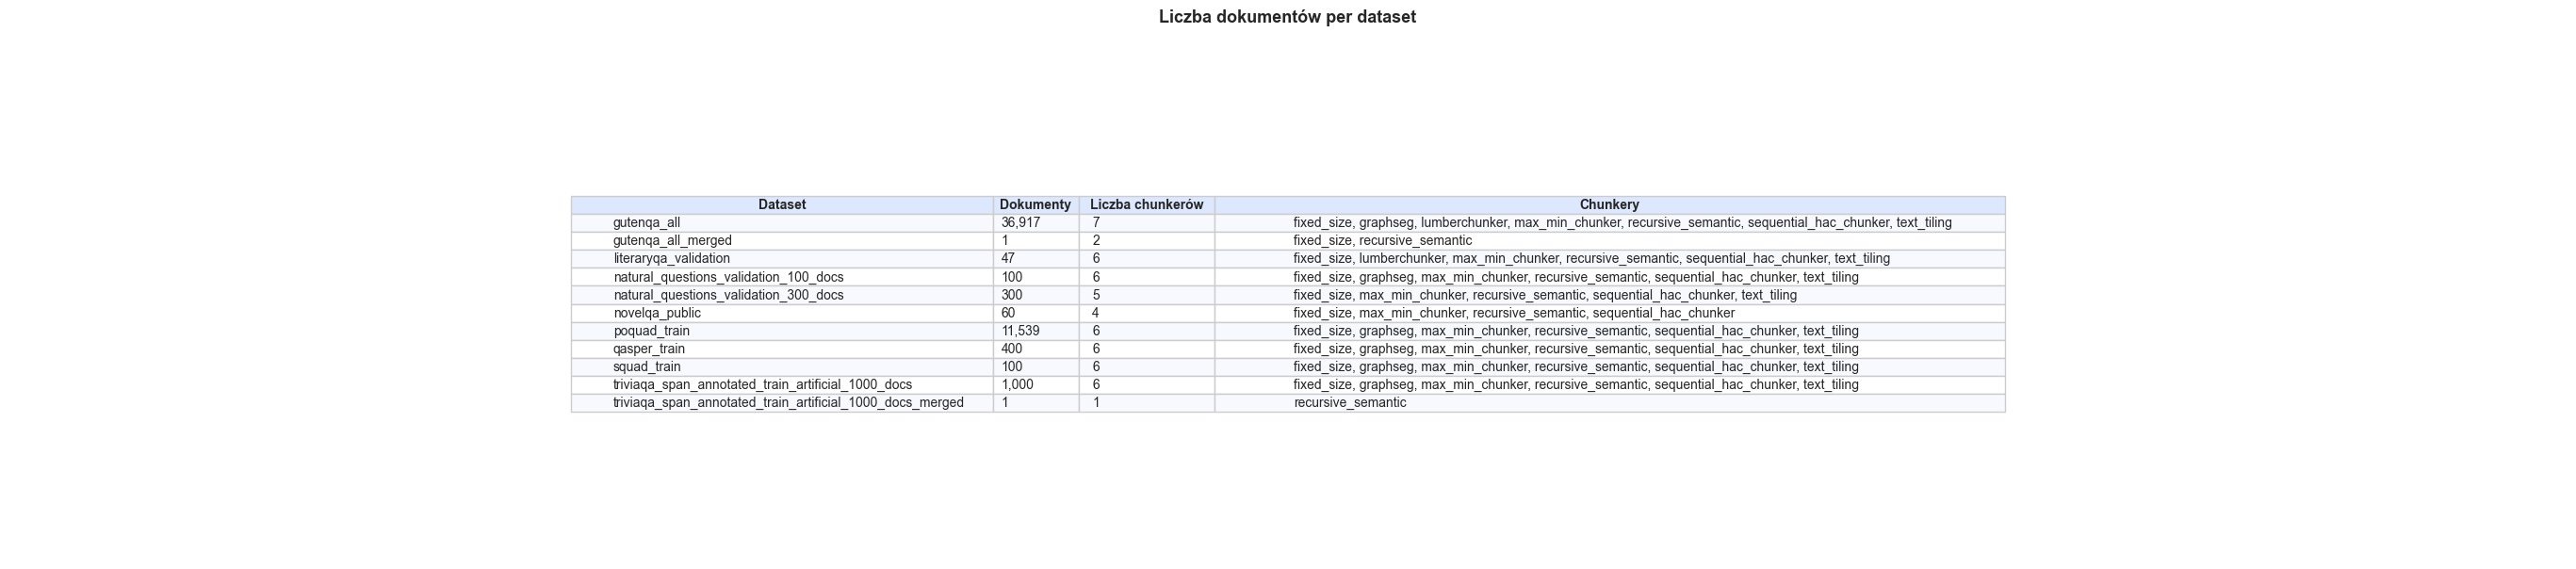

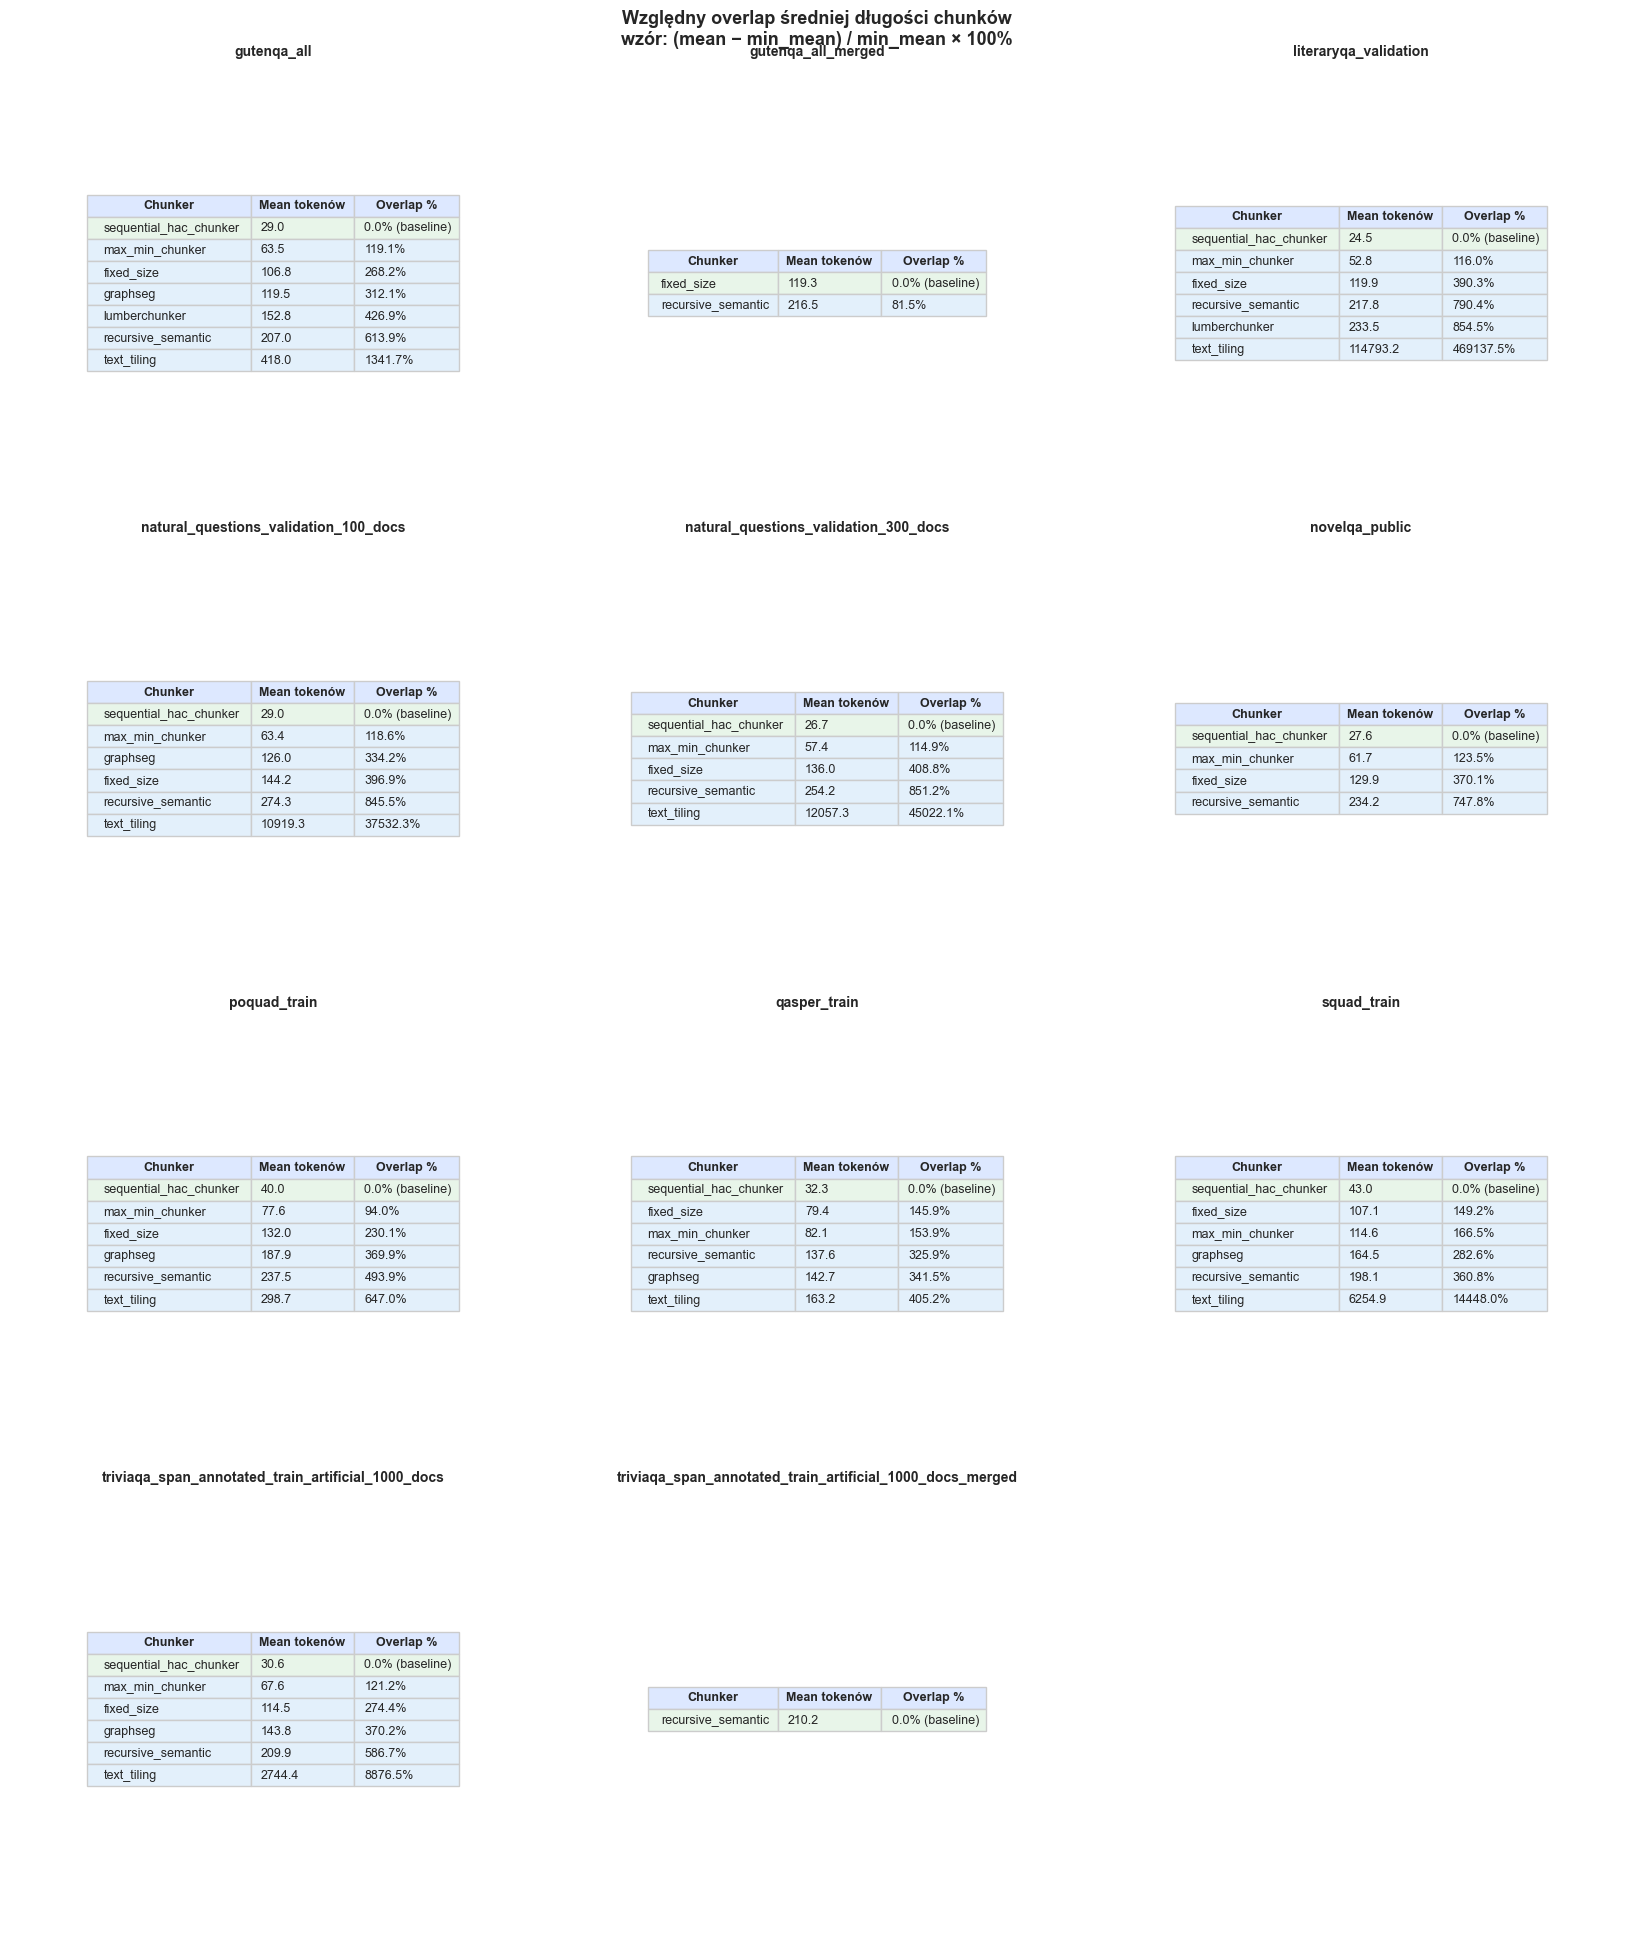

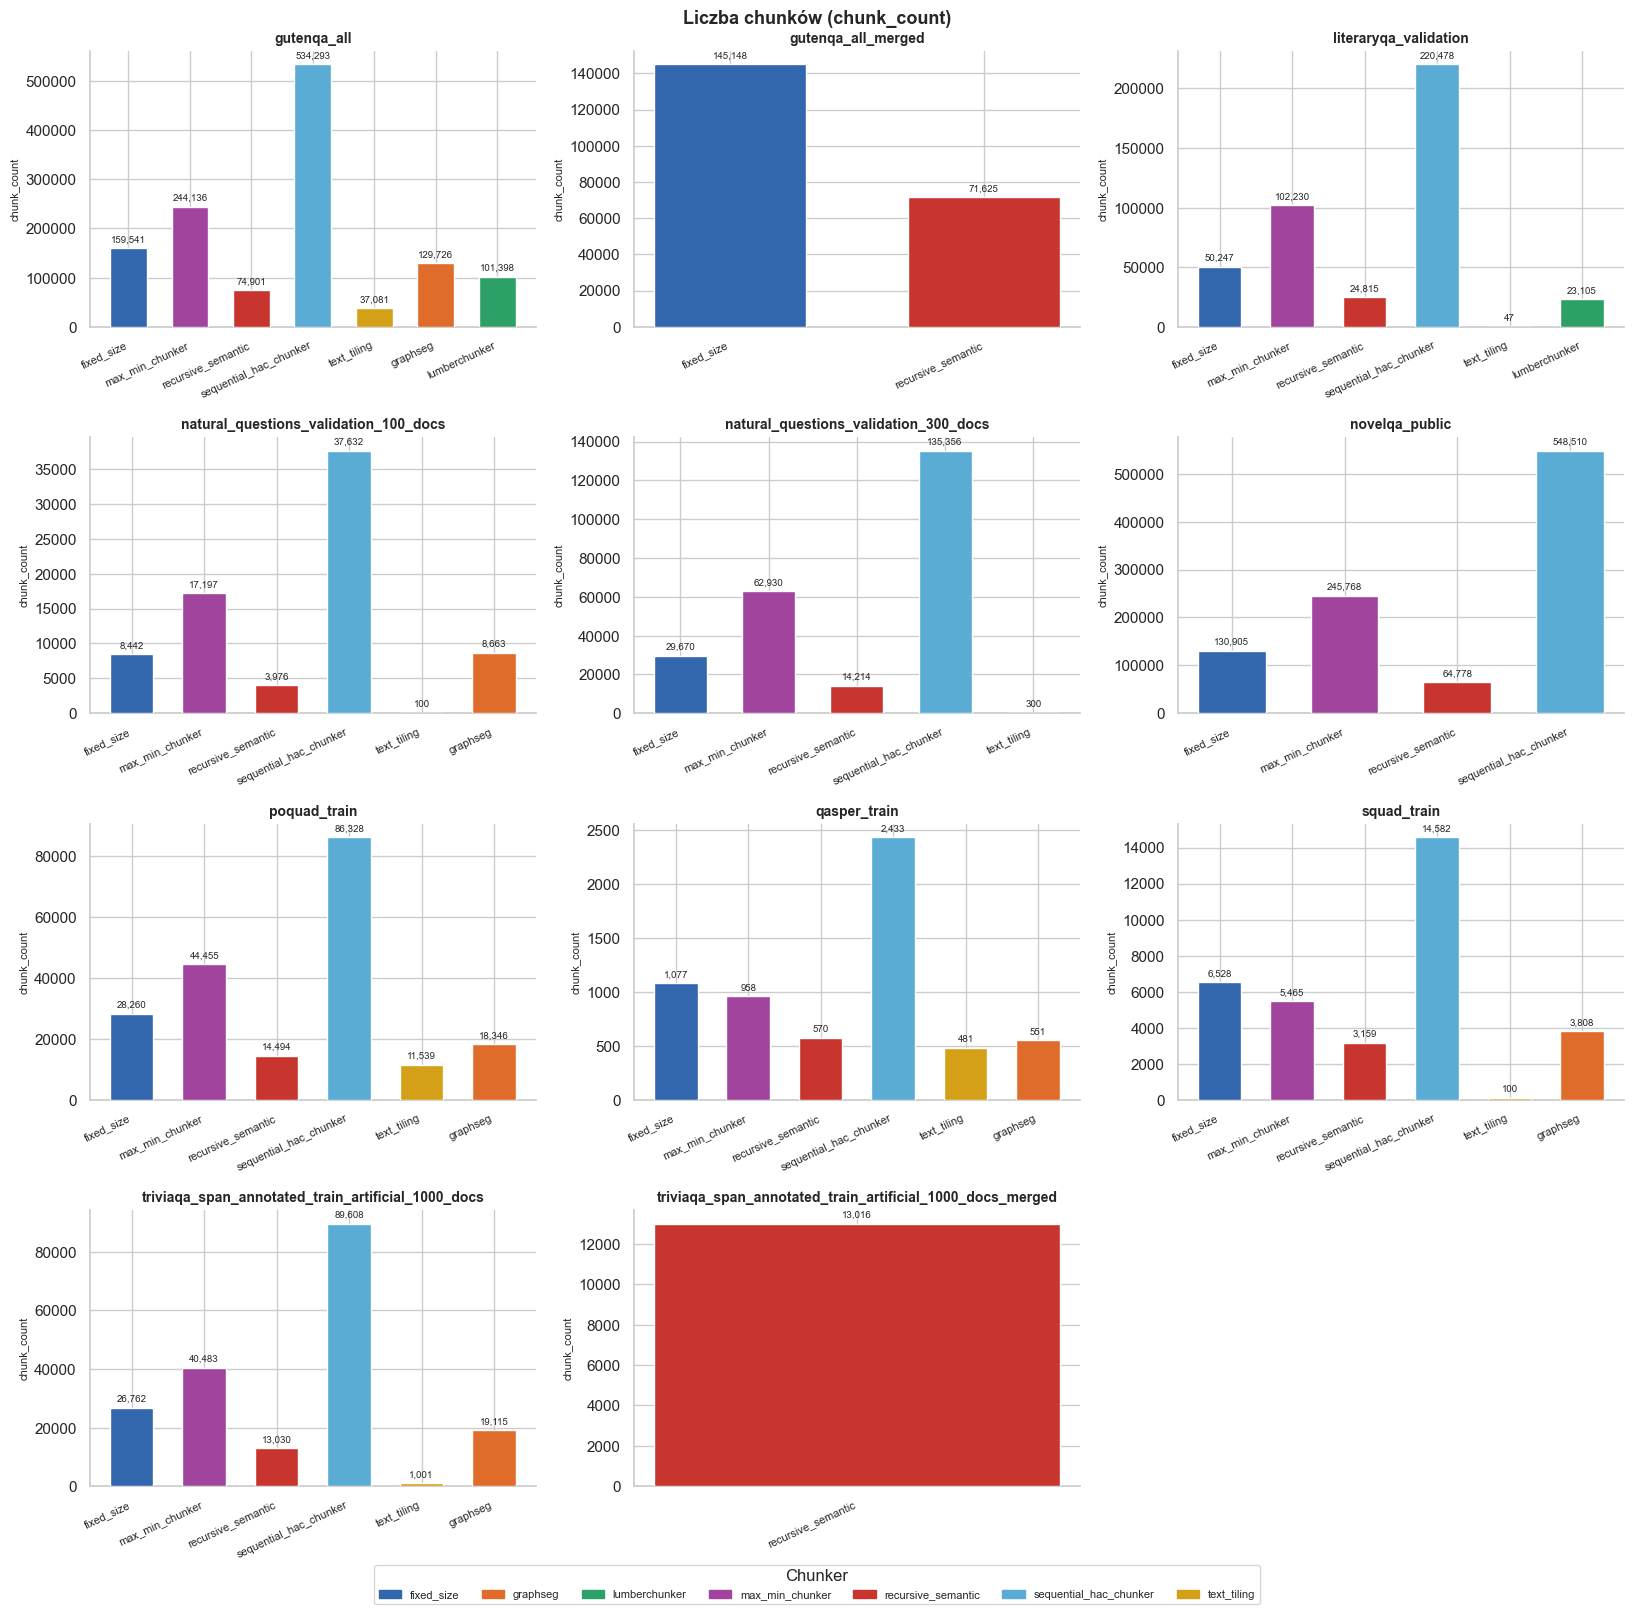

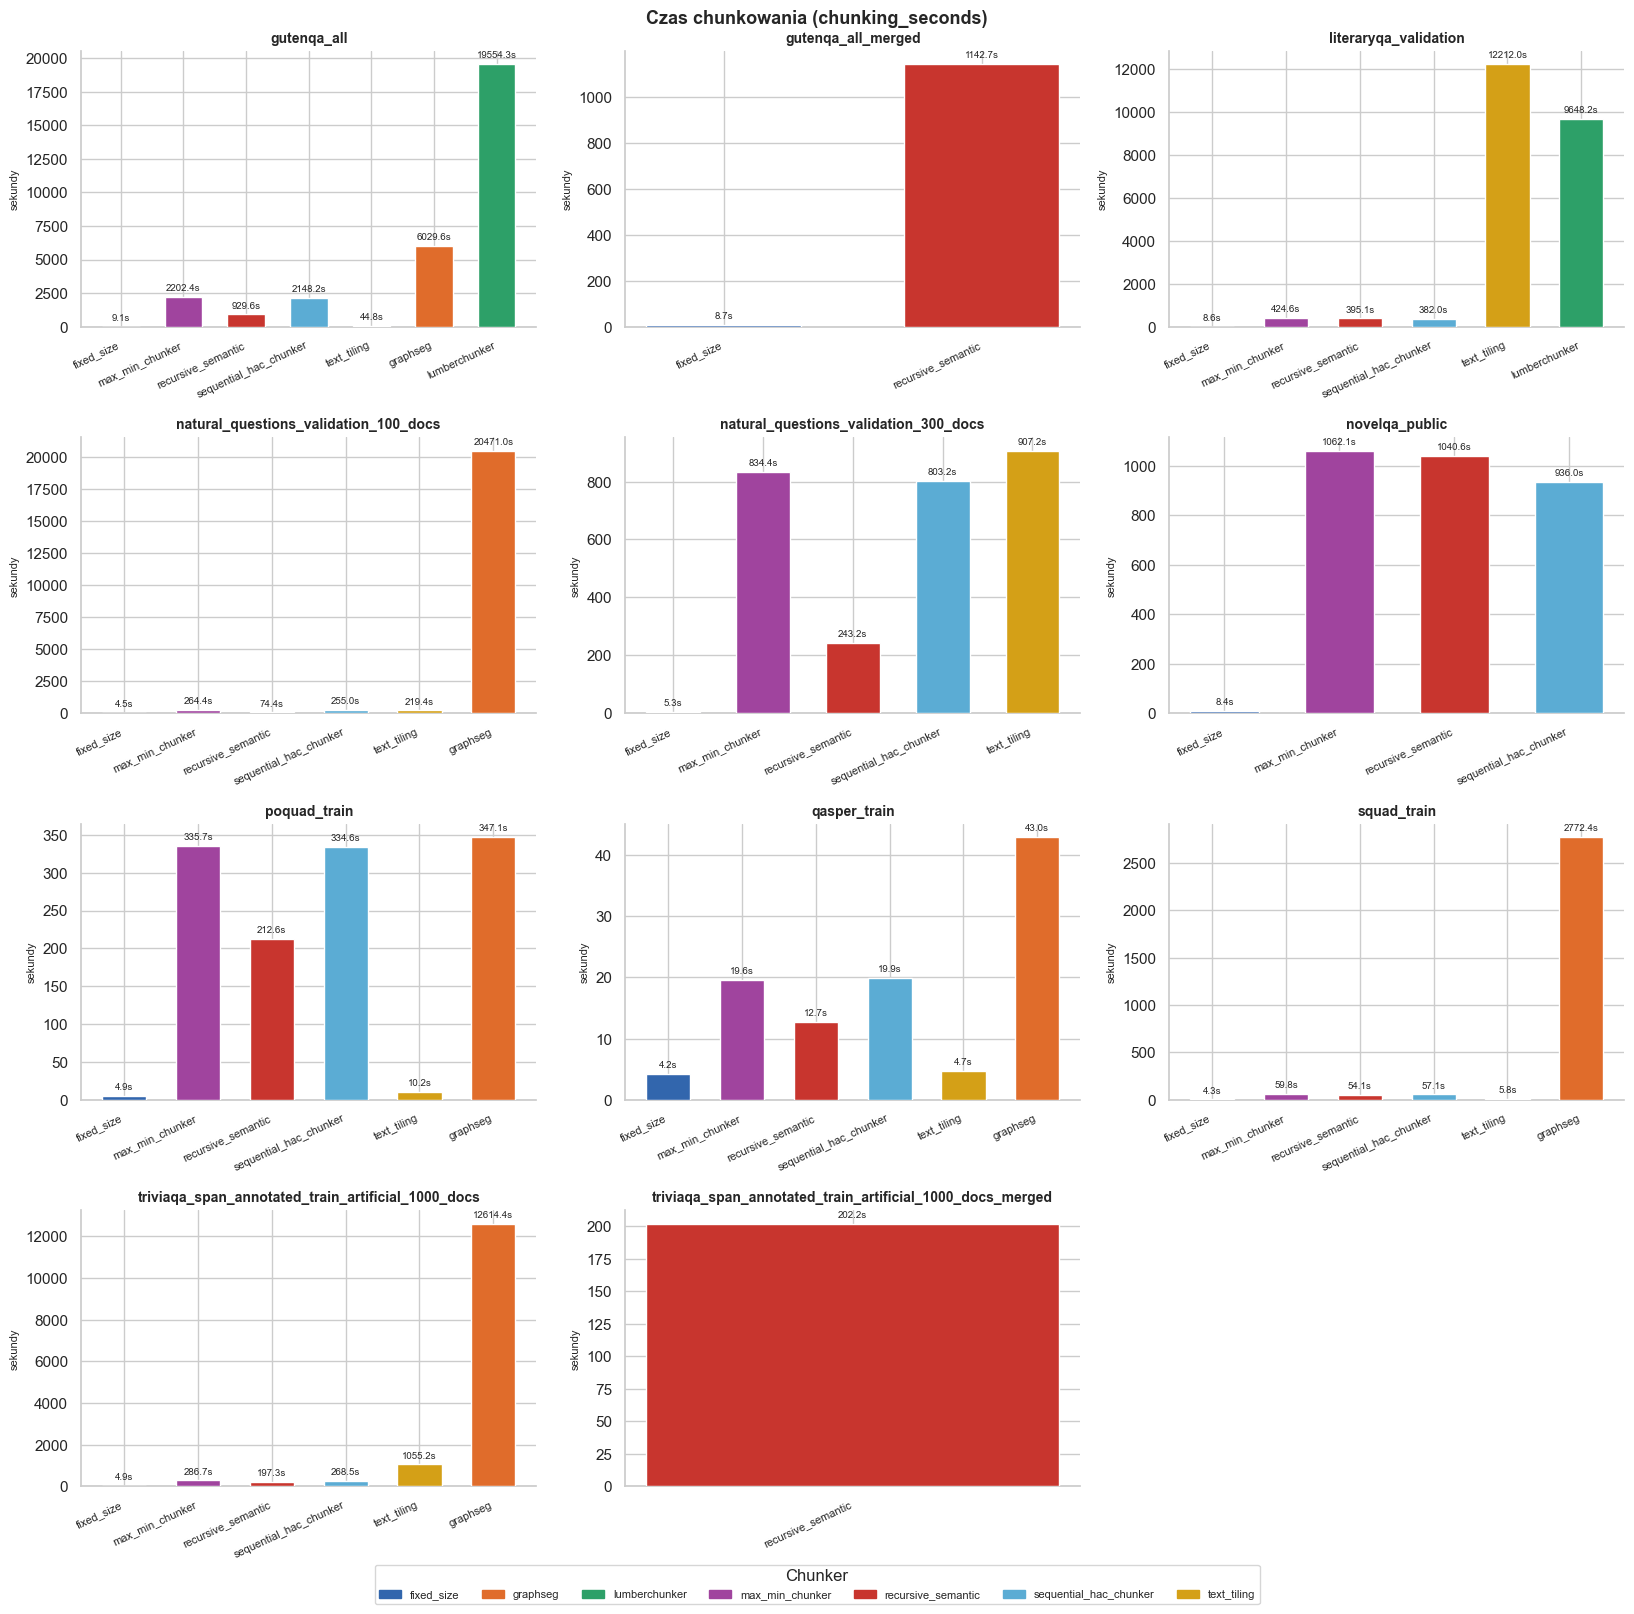

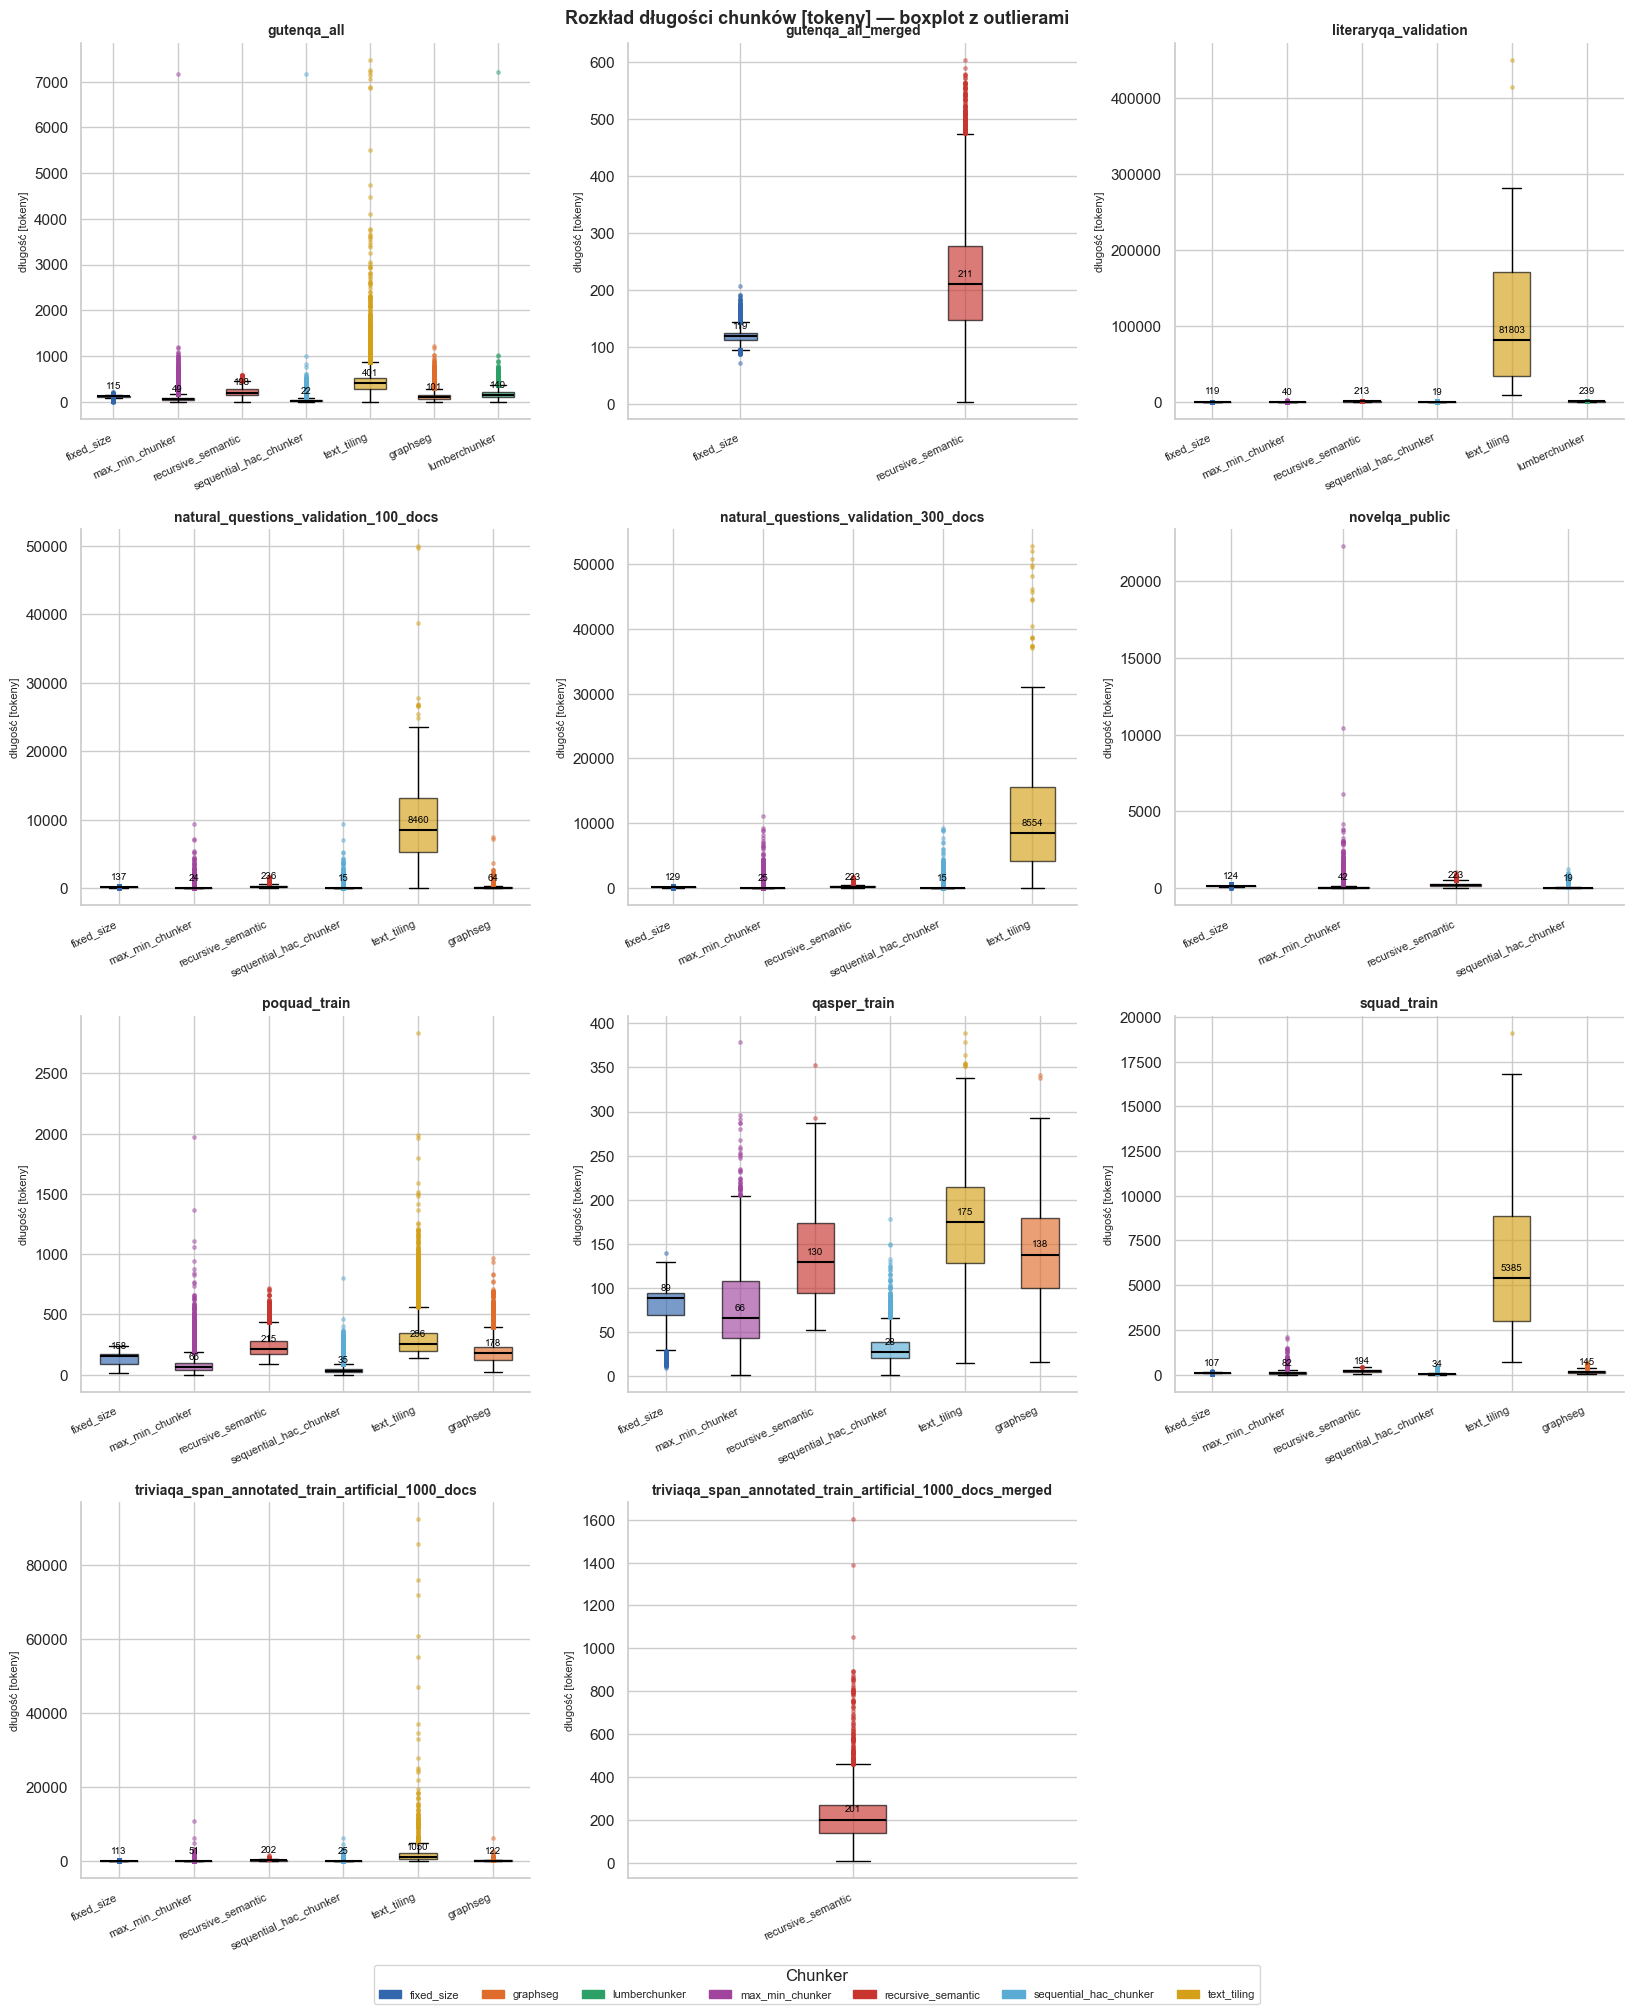

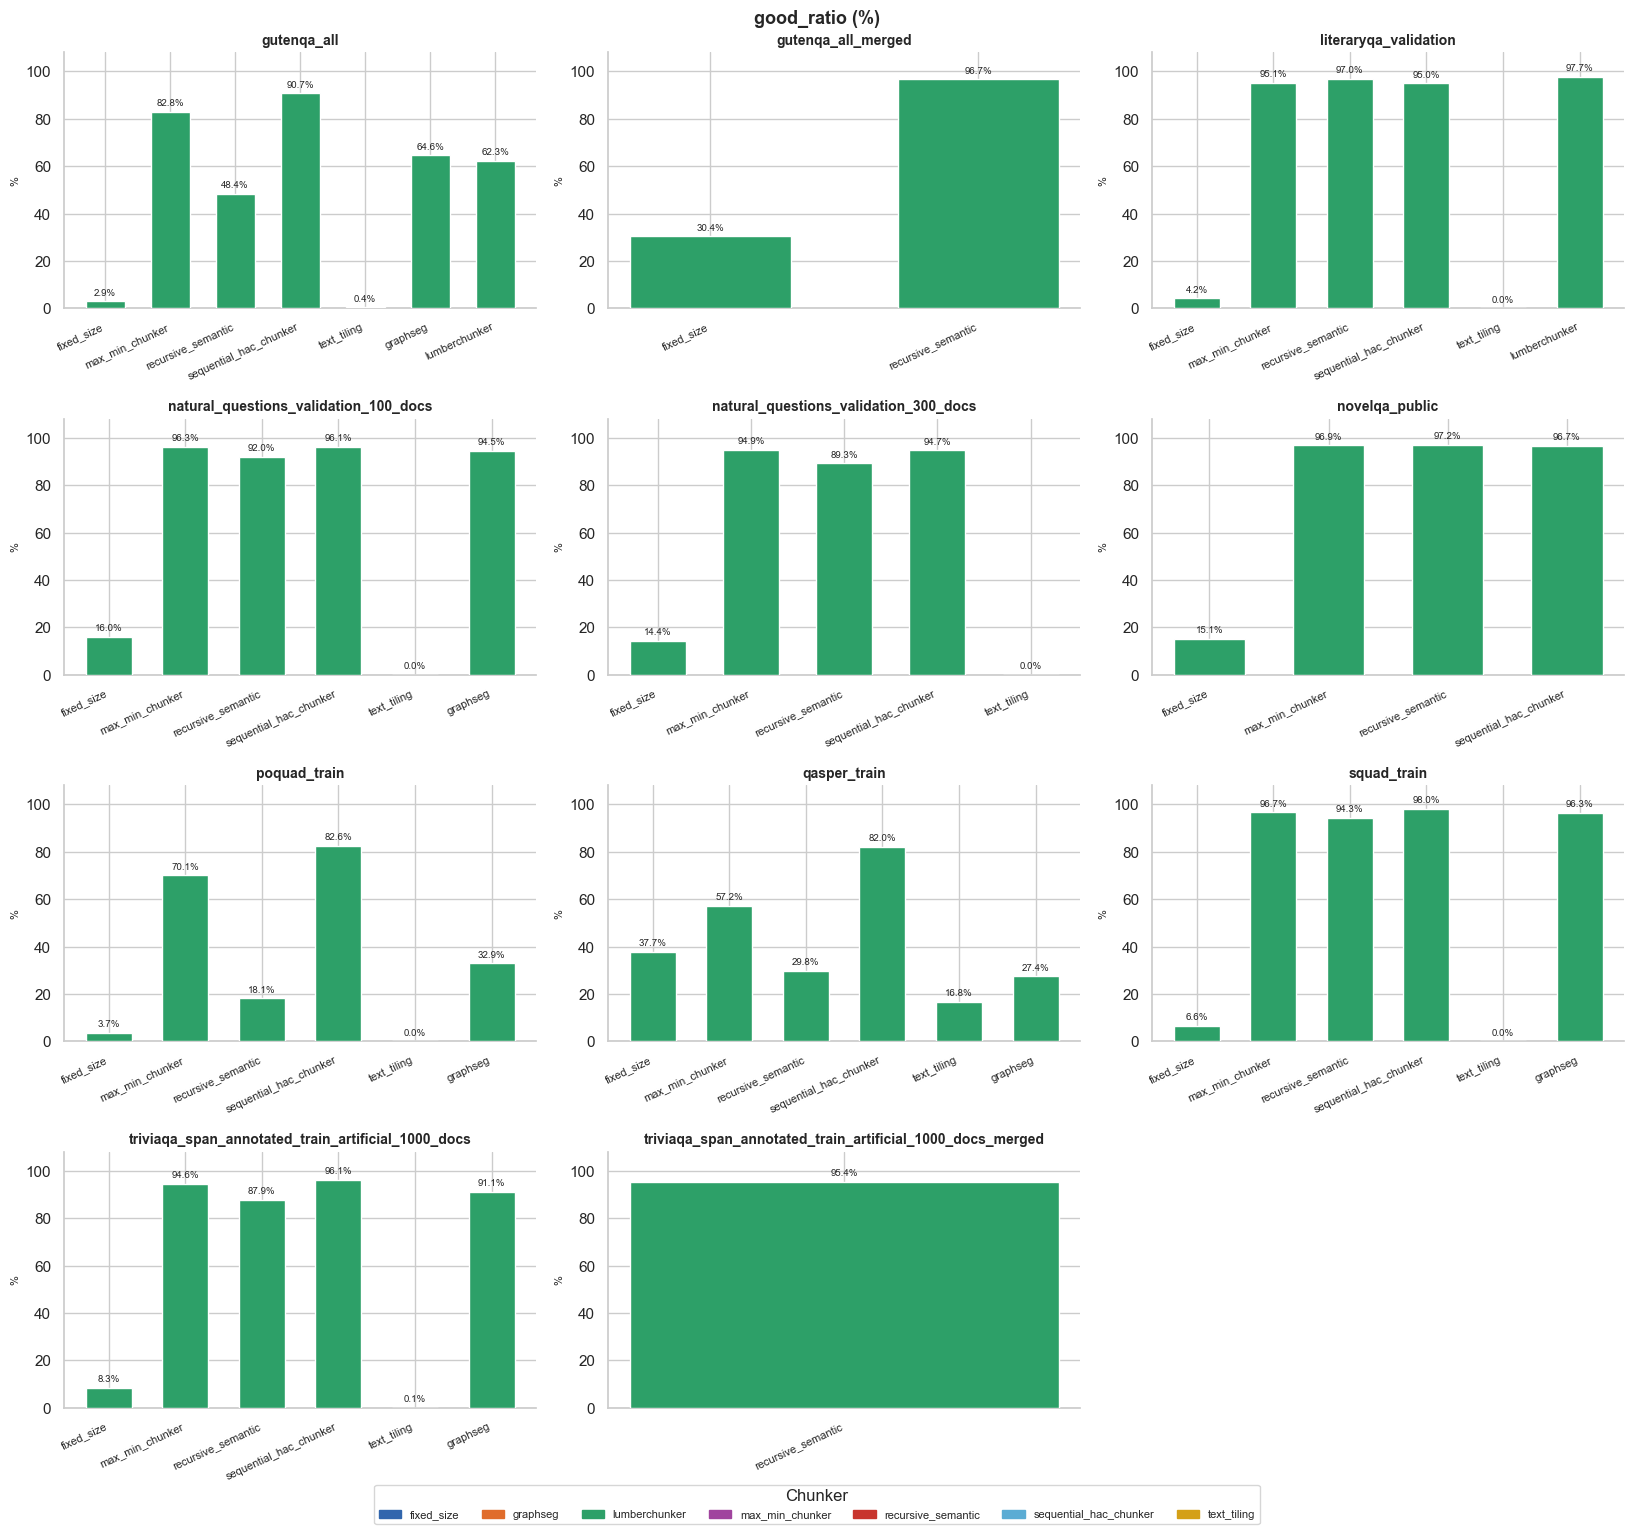

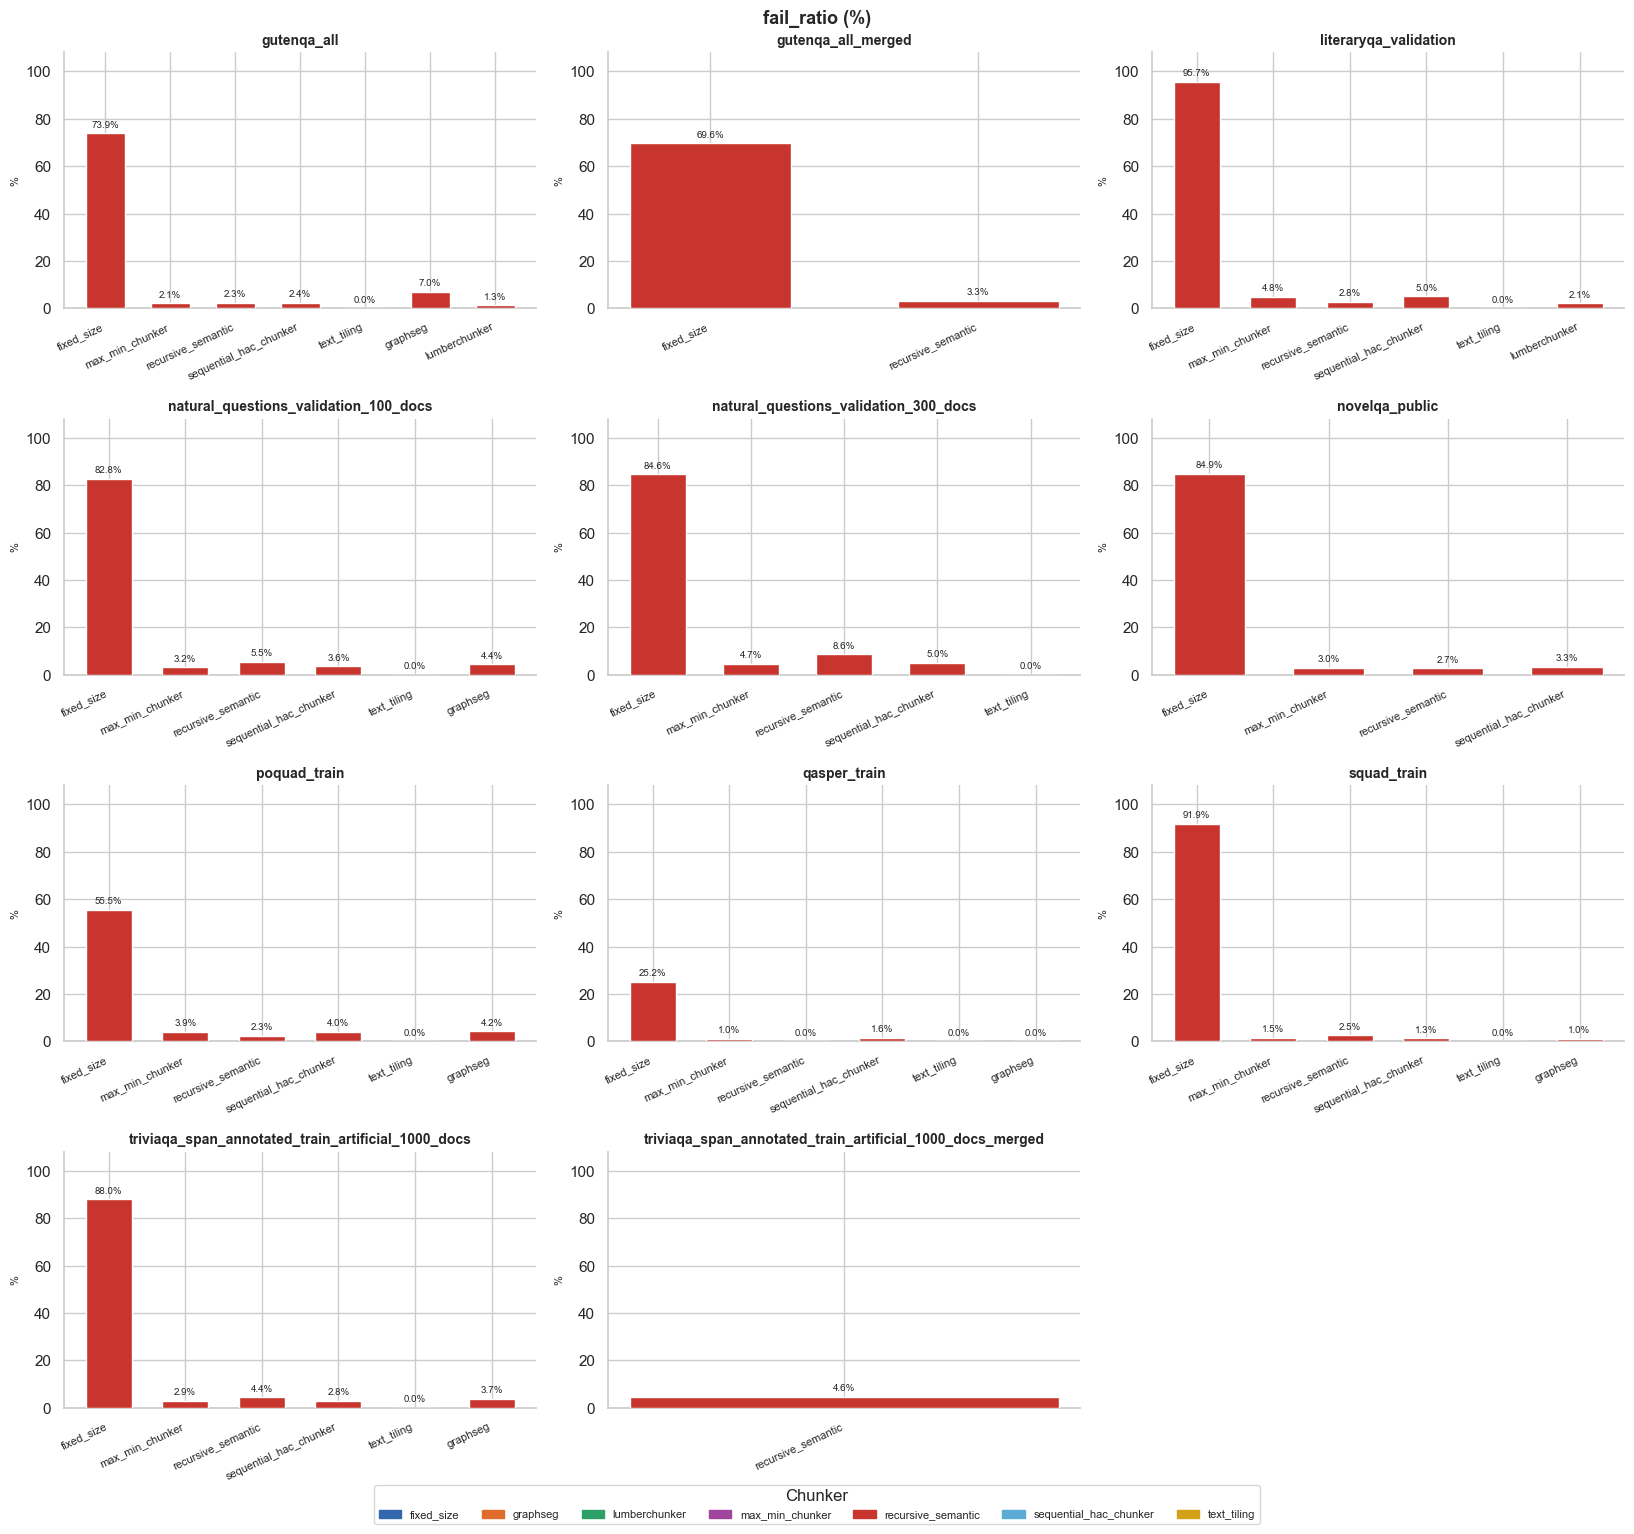

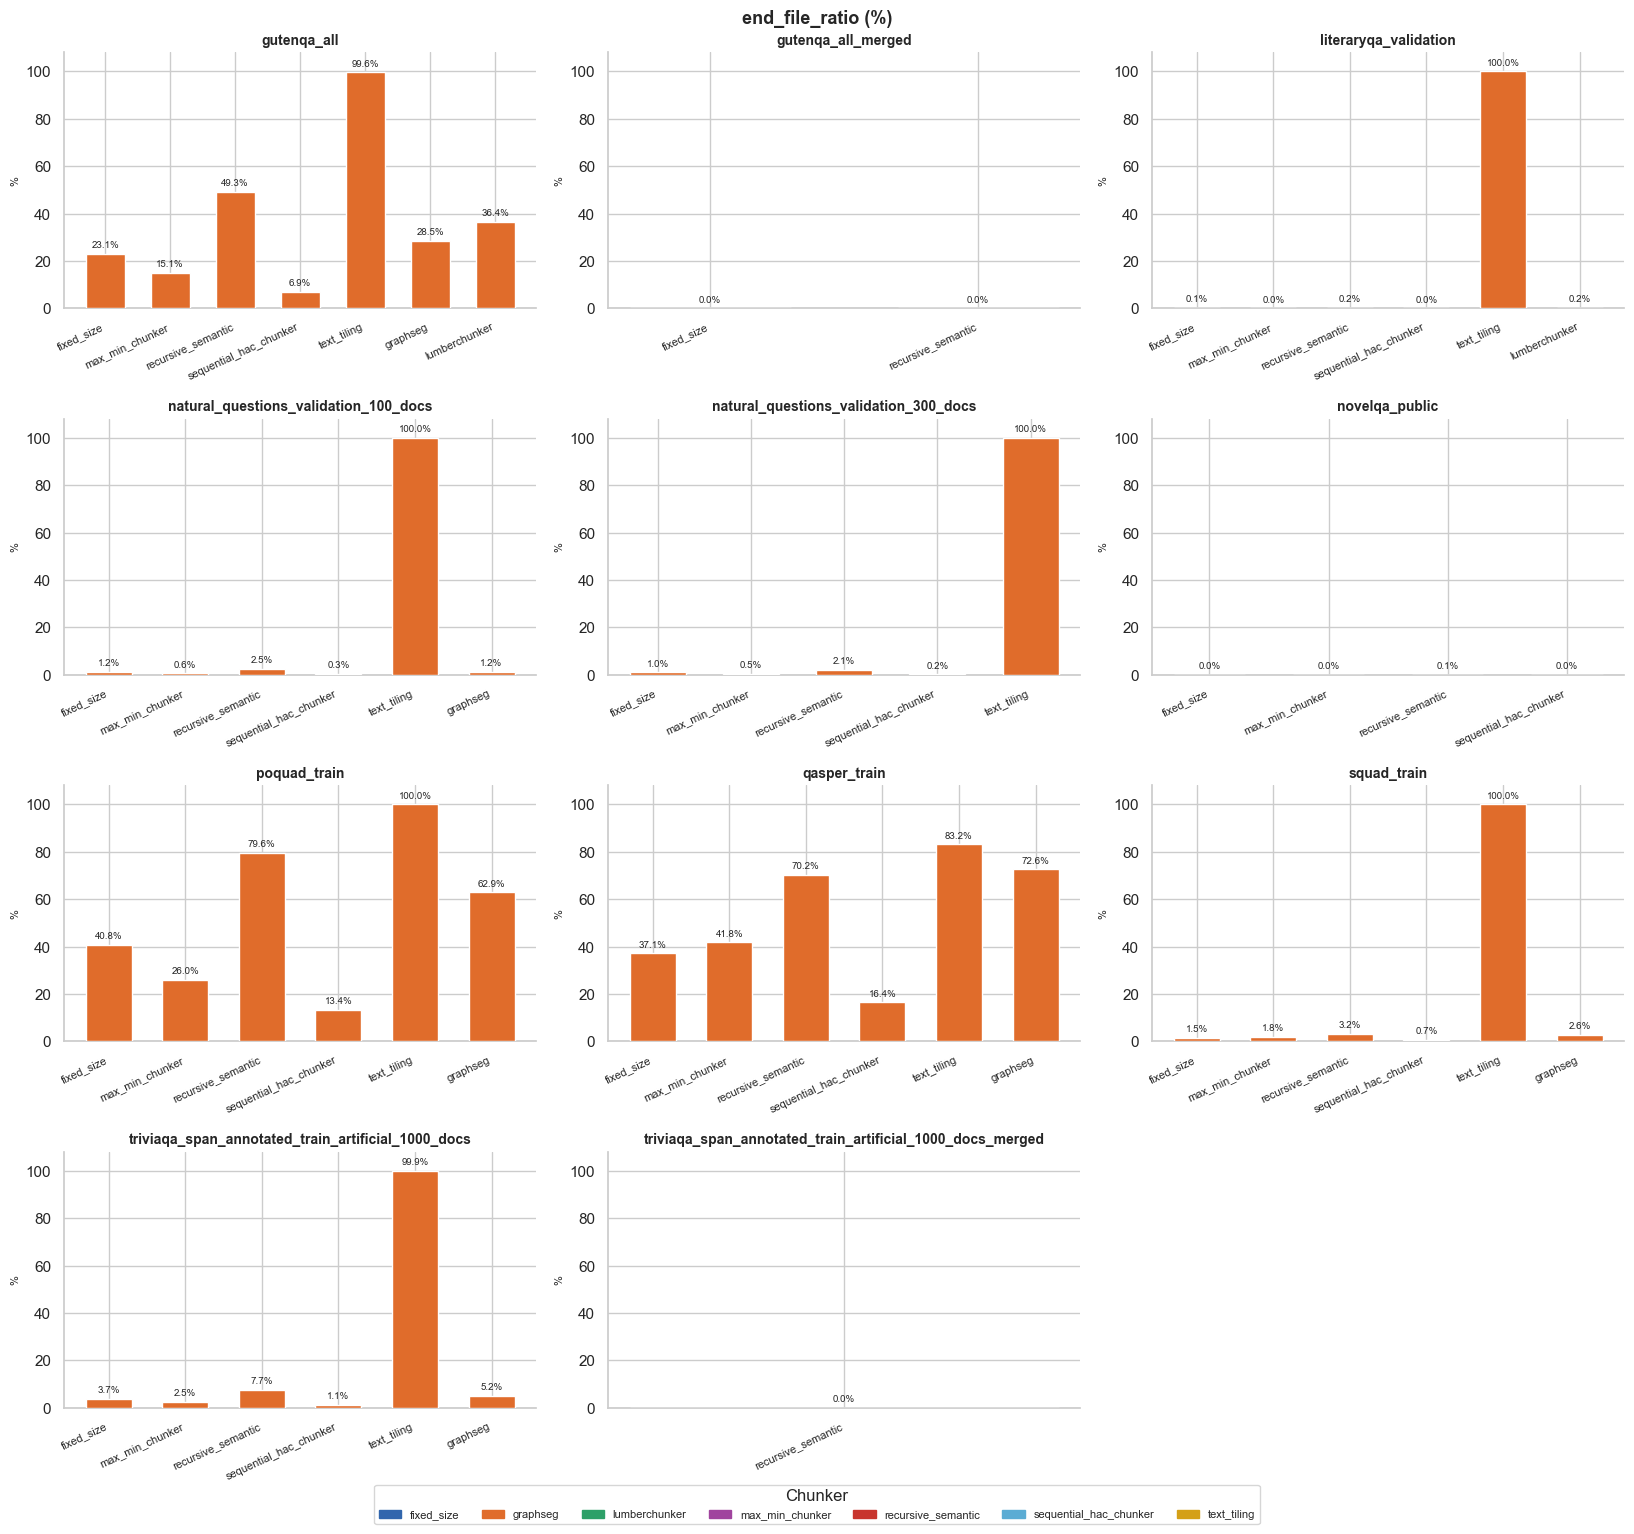

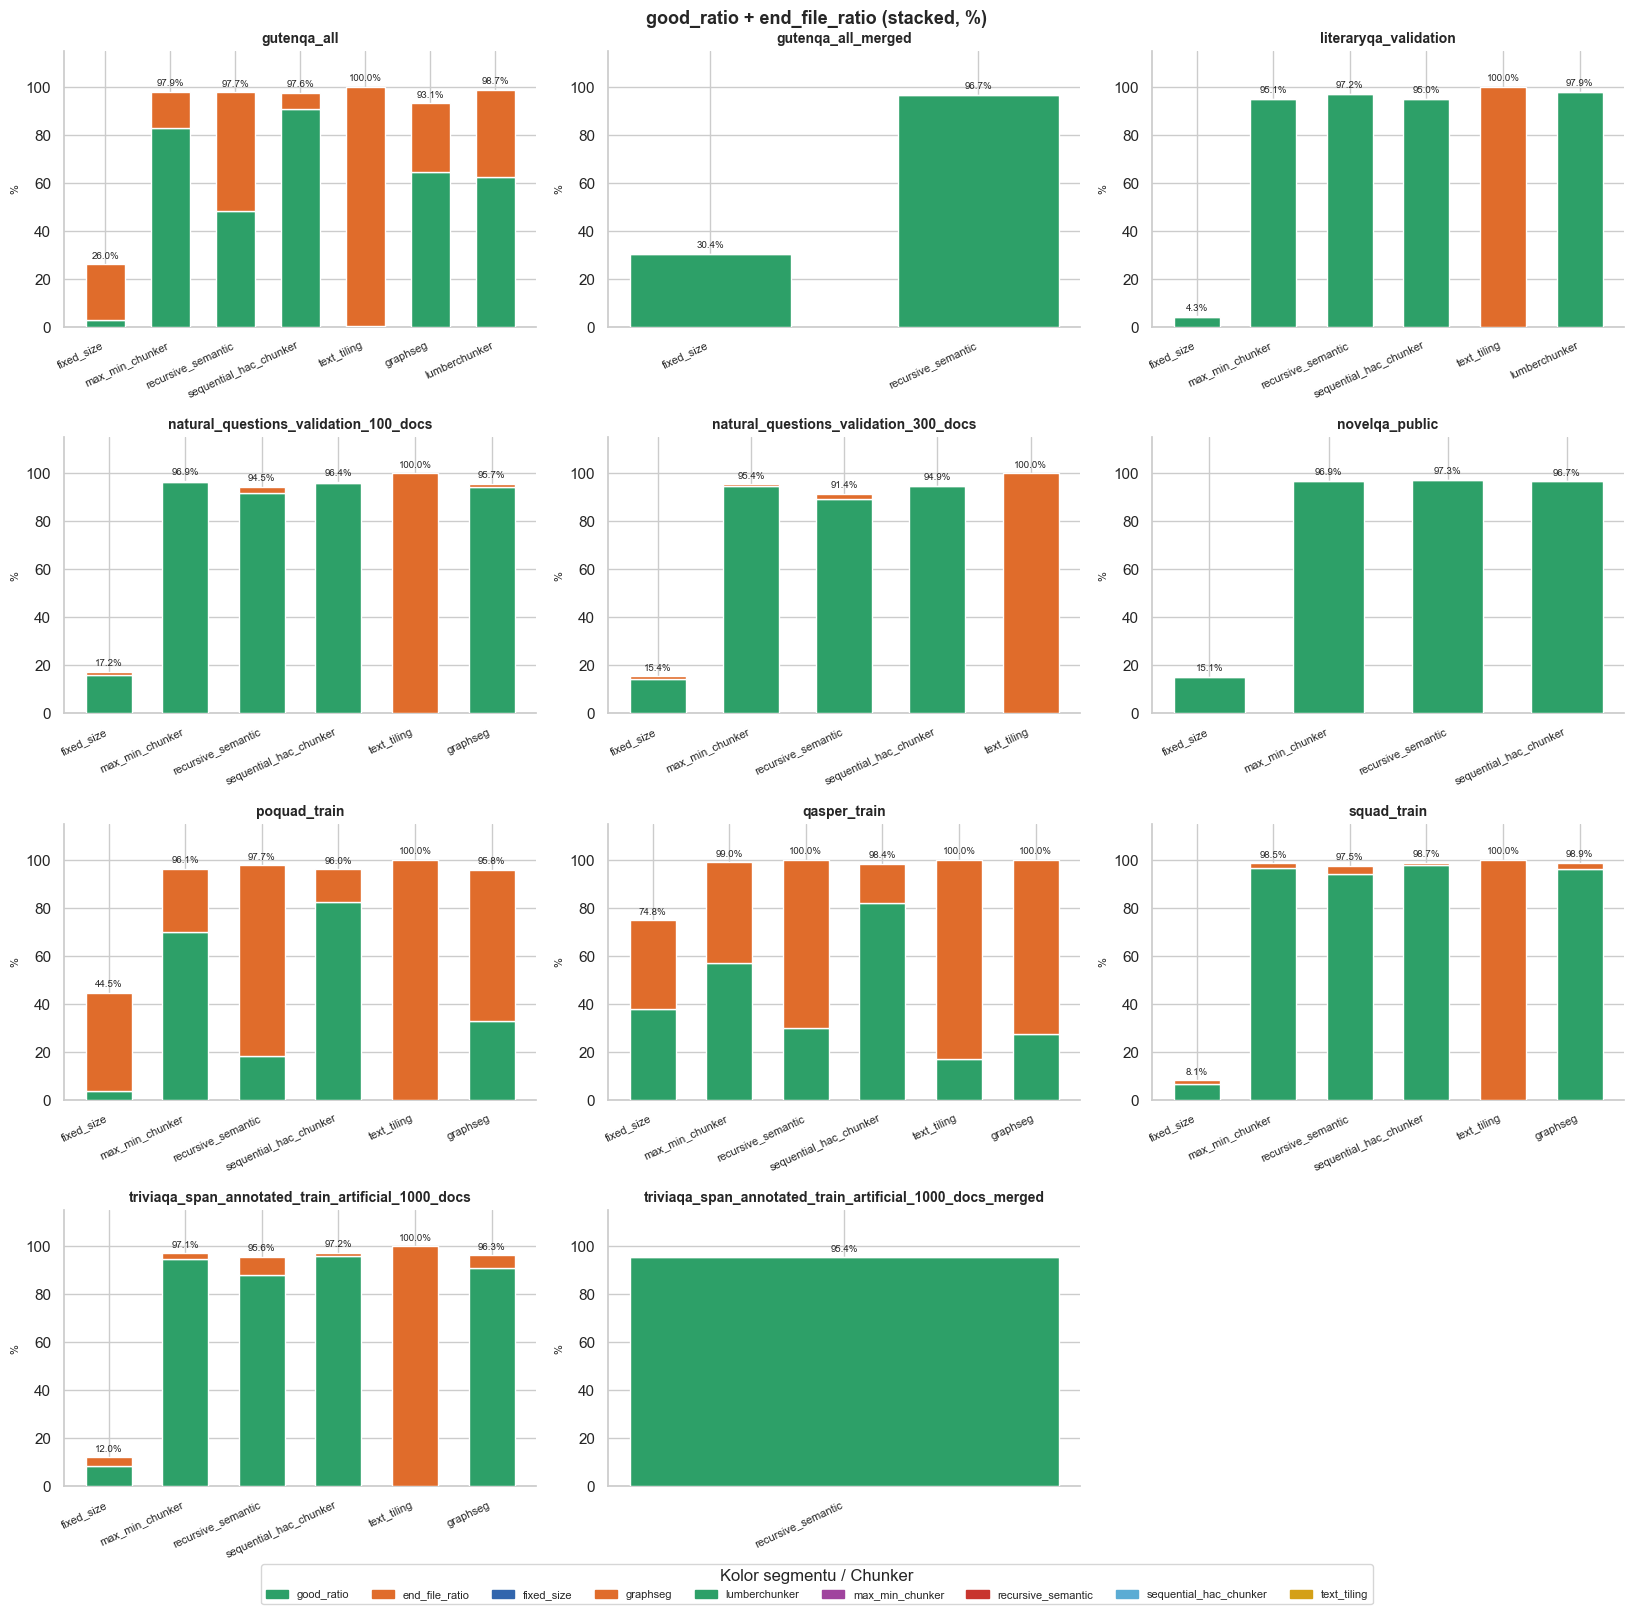

In [17]:
show_dashboard(df)